# Barcode Decode (RGB / Red channel): Native vs SAA vs SAA+IBP — NEW dataset

Run `sweep_sr_barcodes_rgb_NEW.py` first to generate `sr_output/` in each session folder.

SR is performed on the **red Bayer channel** (RGGB → even rows/cols).
Each SR output is 1536 × 2048 (= full sensor resolution, 2× the red-channel LR size).

Each calibration set × repetition is processed independently (5 calibrations × 2 reps = 10 SR runs per session).

**Kernel: Python 3.10 (sr310)**  (`conda activate sr310`)

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import zxingcpp

NB_DIR        = os.path.dirname(os.path.abspath("barcode_decode_rgb_NEW.ipynb"))
METHOD_NAMES  = ["Native-2x", "SAA", "SAA+IBP"]
COLORS_METHOD = {"Native-2x": "C0", "SAA": "C2", "SAA+IBP": "C3"}
name_map      = {"Native-2x": "native_2x", "SAA": "SAA", "SAA+IBP": "SAA_IBP"}

# ── Discover sessions ──────────────────────────────────────────────────────
sessions_available = sorted([
    d for d in os.listdir(NB_DIR)
    if os.path.isdir(os.path.join(NB_DIR, d))
    and any(c.startswith('color_') for c in os.listdir(os.path.join(NB_DIR, d)))
])
print("Sessions:")
for s in sessions_available:
    print(f"  {s}")

# ── Discover SR runs (calib × rep × psf_type) per session ─────────────────
all_runs = []
for session in sessions_available:
    session_path = os.path.join(NB_DIR, session)
    # Find all sr_output* directories
    sr_roots = sorted([
        d for d in os.listdir(session_path)
        if d.startswith('sr_output') and os.path.isdir(os.path.join(session_path, d))
    ])
    for sr_root_name in sr_roots:
        # Determine PSF type from directory name
        if sr_root_name == 'sr_output':
            psf_type = 'measured'
        elif sr_root_name.startswith('sr_output_gaussian'):
            psf_type = sr_root_name.replace('sr_output_', '')  # e.g. 'gaussian_s1.0'
        else:
            psf_type = sr_root_name

        sr_root = os.path.join(session_path, sr_root_name)
        for calib_name in sorted(os.listdir(sr_root)):
            calib_path = os.path.join(sr_root, calib_name)
            if not os.path.isdir(calib_path):
                continue
            for rep_name in sorted(os.listdir(calib_path)):
                rep_path = os.path.join(calib_path, rep_name)
                if not os.path.isdir(rep_path) or not rep_name.startswith('rep'):
                    continue
                if os.path.exists(os.path.join(rep_path, 'done.flag')):
                    all_runs.append({
                        'session':  session,
                        'calib':    calib_name,
                        'rep':      rep_name,
                        'sr_dir':   rep_path,
                        'psf_type': psf_type,
                    })

psf_types = sorted(set(r['psf_type'] for r in all_runs))
print(f"\nPSF types found: {psf_types}")
print(f"{len(all_runs)} SR run(s) ready:")
for r in all_runs[:5]:
    print(f"  {r['session']} / {r['calib']} / {r['rep']} [{r['psf_type']}]")
if len(all_runs) > 5:
    print(f"  ... and {len(all_runs) - 5} more")

Sessions:
  20260407_135002_barcode_new_colour_two_three_four_mil
  20260408_115011_barcodes_new_colour_four_six_mil

PSF types found: ['gaussian_s1.5', 'measured']
40 SR run(s) ready:
  20260407_135002_barcode_new_colour_two_three_four_mil / color_nominal_1.0px_settle50ms / rep00 [measured]
  20260407_135002_barcode_new_colour_two_three_four_mil / color_nominal_1.0px_settle50ms / rep01 [measured]
  20260407_135002_barcode_new_colour_two_three_four_mil / color_special_20260326_123627_1.0px_settle50ms / rep00 [measured]
  20260407_135002_barcode_new_colour_two_three_four_mil / color_special_20260326_123627_1.0px_settle50ms / rep01 [measured]
  20260407_135002_barcode_new_colour_two_three_four_mil / color_special_20260326_151341_1.0px_settle50ms / rep00 [measured]
  ... and 35 more


## Short labels for calibration sets

Create short labels for plotting (e.g. `nominal`, `cal_0326_1236`, ...).

In [18]:
def short_calib_label(calib_name):
    """Shorten 'color_nominal_1.0px_settle50ms' → 'nominal', etc."""
    if 'nominal' in calib_name:
        return 'nominal'
    # color_special_20260326_123627_1.0px_settle50ms → cal_0326_1236
    parts = calib_name.split('_')
    # parts: ['color', 'special', '20260326', '123627', '1.0px', 'settle50ms']
    date_part = parts[2][4:]  # '0326'
    time_part = parts[3][:4]  # '1236'
    return f'cal_{date_part}_{time_part}'

def run_label(run):
    return f"{short_calib_label(run['calib'])} / {run['rep']}"

# Test
for r in all_runs[:3]:
    print(f"  {run_label(r)}  ←  {r['calib']}/{r['rep']}")

  nominal / rep00  ←  color_nominal_1.0px_settle50ms/rep00
  nominal / rep01  ←  color_nominal_1.0px_settle50ms/rep01
  cal_0326_1236 / rep00  ←  color_special_20260326_123627_1.0px_settle50ms/rep00


## ROI Definitions

- `roi` — `(row_start, row_end, col_start, col_end)` in **HR pixel coordinates**
  (HR = 1536 × 2048, same as full sensor resolution)
- `pitch_mil` — barcode bar pitch in mils

Use the viewer cell below to locate coordinates (displayed at 1/4 scale → multiply by 4).

In [33]:
# ══════════════════════════════════════════════════════════════════════════════
# EDIT THIS CELL — fill in ROIs and pitches for every session
# ══════════════════════════════════════════════════════════════════════════════

SESSION_ROIS = {
    "20260407_135002_barcode_new_colour_two_three_four_mil": [
        {"label": "2 mil", "roi": (200*4, 305*4, 90*4, 230*4), "pitch_mil": 2},
        {"label": "3 mil", "roi": (200*4, 305*4, 250*4, 445*4), "pitch_mil": 3},
        {"label": "5 mil", "roi": (75*4, 185*4, 95*4, 400*4), "pitch_mil": 5},
    ],
    "20260408_115011_barcodes_new_colour_four_six_mil": [
        {"label": "4 mil", "roi": (210*4, 320*4, 150*4, 400*4), "pitch_mil": 4},
        {"label": "6 mil", "roi": (90*4, 200*4, 100*4, 470*4), "pitch_mil": 6},
    ],
}

for session in sessions_available:
    assert session in SESSION_ROIS, f"Missing SESSION_ROIS entry for: {session}"
    for bc in SESSION_ROIS[session]:
        assert None not in bc["roi"],       f"Fill in ROI for {session} / {bc['label']}"
        assert bc["pitch_mil"] is not None, f"Fill in pitch_mil for {session} / {bc['label']}"

print("All ROIs defined:")
for session, barcodes in SESSION_ROIS.items():
    if session in sessions_available:
        print(f"  {session}  →  {', '.join(str(bc['pitch_mil'])+' mil' for bc in barcodes)}")

All ROIs defined:
  20260407_135002_barcode_new_colour_two_three_four_mil  →  2 mil, 3 mil, 5 mil
  20260408_115011_barcodes_new_colour_four_six_mil  →  4 mil, 6 mil


## Image Viewer — Locate Barcode Coordinates

Displayed at 1/4 scale. Multiply any coordinate by 4 to get HR pixel coordinates.

Shows the first available SR run's Native-2x image per session.

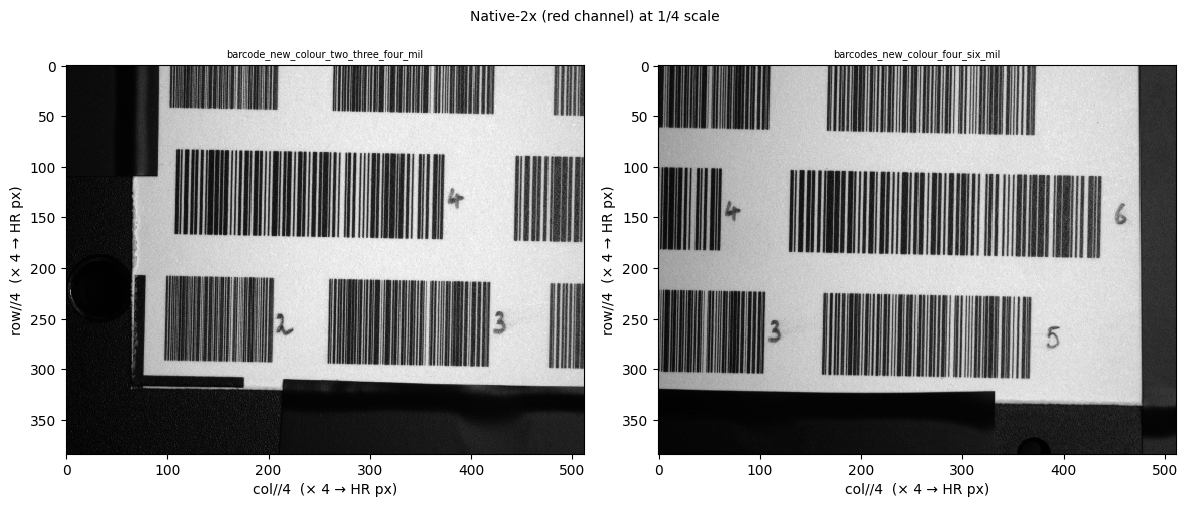

In [34]:
DS = 4  # display downscale (multiply imshow coords × DS to get HR pixels)

n_sessions = len(sessions_available)
fig, axes  = plt.subplots(1, n_sessions, figsize=(6 * n_sessions, 5), squeeze=False)

for ax, session in zip(axes[0], sessions_available):
    # Pick first available run for this session
    run = next(r for r in all_runs if r['session'] == session)
    img = np.array(Image.open(os.path.join(run['sr_dir'], 'native_2x.png')))
    ax.imshow(img[::DS, ::DS], cmap='gray', interpolation='nearest')
    ax.set_title(session[16:], fontsize=7)
    ax.set_xlabel(f'col//{DS}  (× {DS} → HR px)')
    ax.set_ylabel(f'row//{DS}  (× {DS} → HR px)')

plt.suptitle(f'Native-2x (red channel) at 1/{DS} scale', fontsize=10)
plt.tight_layout()
plt.show()

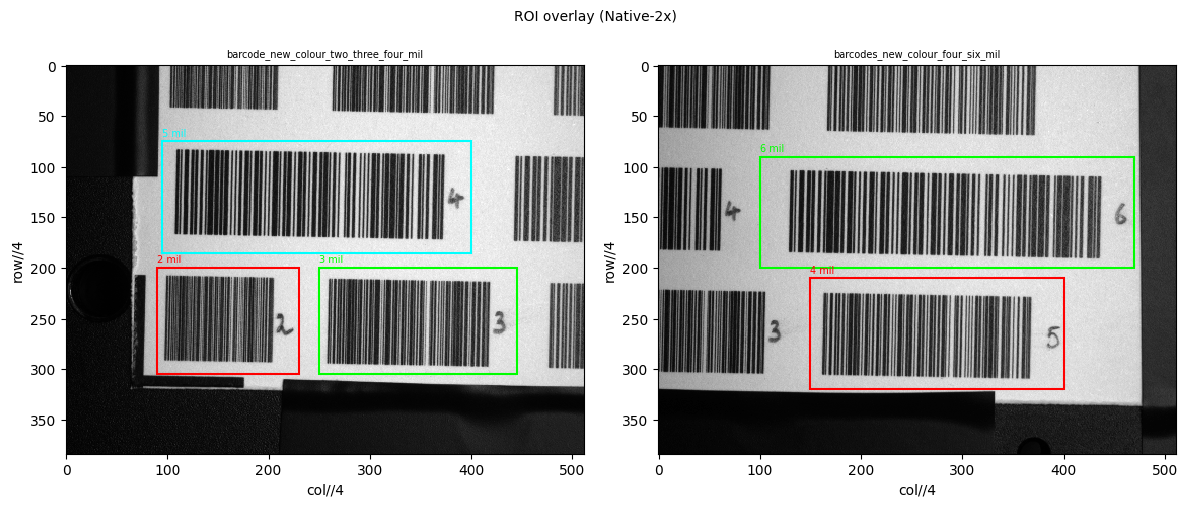

In [35]:
# ROI overlay — draw defined barcodes on top of each session image
ROI_COLORS = ["red", "lime", "cyan", "orange", "magenta"]

n_sessions = len(sessions_available)
fig, axes = plt.subplots(1, n_sessions, figsize=(6 * n_sessions, 5), squeeze=False)

for ax, session in zip(axes[0], sessions_available):
    run = next(r for r in all_runs if r['session'] == session)
    img = np.array(Image.open(os.path.join(run['sr_dir'], 'native_2x.png')))
    ax.imshow(img[::DS, ::DS], cmap='gray', interpolation='nearest')

    for i, bc in enumerate(SESSION_ROIS[session]):
        r0, r1, c0, c1 = bc["roi"]
        rect = patches.Rectangle(
            (c0 / DS, r0 / DS), (c1 - c0) / DS, (r1 - r0) / DS,
            linewidth=1.5, edgecolor=ROI_COLORS[i % len(ROI_COLORS)],
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(c0 / DS, r0 / DS - 3, bc["label"],
                color=ROI_COLORS[i % len(ROI_COLORS)], fontsize=7, va='bottom')

    ax.set_title(session[16:], fontsize=7)
    ax.set_xlabel(f'col//{DS}')
    ax.set_ylabel(f'row//{DS}')

plt.suptitle('ROI overlay (Native-2x)', fontsize=10)
plt.tight_layout()
plt.show()

## Decode Function

In [36]:
N_TRIALS   = 100
MAX_JITTER = 2
RNG        = np.random.default_rng(42)


def decode_confidence(img_gray, roi, n_trials=N_TRIALS, max_jitter=MAX_JITTER):
    r0, r1, c0, c1 = roi
    H, W = img_gray.shape

    centre_res = zxingcpp.read_barcodes(img_gray[r0:r1, c0:c1])
    text       = centre_res[0].text if centre_res else None

    successes = 0
    for _ in range(n_trials):
        dr = int(RNG.integers(-max_jitter, max_jitter + 1))
        dc = int(RNG.integers(-max_jitter, max_jitter + 1))
        rr0 = max(0, r0 + dr);  rr1 = min(H, r1 + dr)
        rc0 = max(0, c0 + dc);  rc1 = min(W, c1 + dc)
        crop = img_gray[rr0:rr1, rc0:rc1]
        if crop.size > 0 and zxingcpp.read_barcodes(crop):
            successes += 1

    return text, successes / n_trials


def crop_roi(img_gray, roi):
    r0, r1, c0, c1 = roi
    return img_gray[r0:r1, c0:c1]


print(f"decode_confidence ready  (N_TRIALS={N_TRIALS}, max_jitter={MAX_JITTER} px)")

decode_confidence ready  (N_TRIALS=100, max_jitter=2 px)


## Run Decoding — All Runs × Methods

Each "run" is one calibration set × one repetition.

In [37]:
all_results = []

for run in all_runs:
    session  = run['session']
    sr_dir   = run['sr_dir']
    barcodes = SESSION_ROIS[session]
    imgs     = {m: np.array(Image.open(os.path.join(sr_dir, f'{name_map[m]}.png')))
                for m in METHOD_NAMES}

    print(f"\n{'═'*60}")
    print(f"  {run_label(run)}")
    print(f"{'═'*60}")

    for method in METHOD_NAMES:
        print(f"\n  [{method}]")
        for bc in barcodes:
            text, conf = decode_confidence(imgs[method], bc["roi"])
            all_results.append({
                "session":    session,
                "calib":      run['calib'],
                "rep":        run['rep'],
                "run_label":  run_label(run),
                "psf_type":   run['psf_type'],
                "method":     method,
                "label":      bc["label"],
                "pitch_mil":  bc["pitch_mil"],
                "text":       text,
                "confidence": conf,
            })
            status = f"'{text}'" if text else "FAIL"
            print(f"    {bc['label']:8s}  {bc['pitch_mil']} mil  "
                  f"conf={conf:.2f}  → {status}")


════════════════════════════════════════════════════════════
  nominal / rep00
════════════════════════════════════════════════════════════

  [Native-2x]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil  conf=0.00  → FAIL
    5 mil     5 mil  conf=0.00  → FAIL

  [SAA]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil  conf=0.00  → FAIL
    5 mil     5 mil  conf=0.00  → FAIL

  [SAA+IBP]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil  conf=0.00  → FAIL
    5 mil     5 mil  conf=0.00  → FAIL

════════════════════════════════════════════════════════════
  nominal / rep01
════════════════════════════════════════════════════════════

  [Native-2x]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil  conf=0.00  → FAIL
    5 mil     5 mil  conf=0.10  → FAIL

  [SAA]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil  conf=0.00  → FAIL
    5 mil     5 mil  conf=0.00  → FAIL

  [SAA+IBP]
    2 mil     2 mil  conf=0.00  → FAIL
    3 mil     3 mil 

## Visual Comparison: Cropped Barcodes per Run

In [ ]:
for run in all_runs:
    if 'gaussian' not in run.get('psf_type', ''):
        continue
    session  = run['session']
    sr_dir   = run['sr_dir']
    barcodes = SESSION_ROIS[session]
    imgs     = {m: np.array(Image.open(os.path.join(sr_dir, f'{name_map[m]}.png')))
                for m in METHOD_NAMES}
    run_res  = [r for r in all_results
                if r['calib'] == run['calib'] and r['rep'] == run['rep']
                and r['session'] == session]

    n_bc, n_met = len(barcodes), len(METHOD_NAMES)
    fig, axes = plt.subplots(n_bc, n_met, figsize=(5 * n_met, 3 * n_bc), squeeze=False)

    for row, bc in enumerate(barcodes):
        for col, method in enumerate(METHOD_NAMES):
            ax   = axes[row][col]
            ax.imshow(crop_roi(imgs[method], bc["roi"]), cmap="gray", interpolation="nearest")
            res  = next(r for r in run_res
                        if r["method"] == method and r["pitch_mil"] == bc["pitch_mil"])
            ax.set_title(f"{method}\nconf={res['confidence']:.2f}  '{res['text'] or '—'}'",
                         fontsize=8)
            ax.axis("off")
        axes[row][0].set_ylabel(f"{bc['label']}\n{bc['pitch_mil']} mil",
                                fontsize=9, rotation=0, ha="right", va="center", labelpad=5)

    plt.suptitle(run_label(run), fontsize=9, y=1.01)
    plt.tight_layout()
    plt.show()

## Decode Confidence vs Barcode Pitch

Averaged across all calibrations and repetitions.

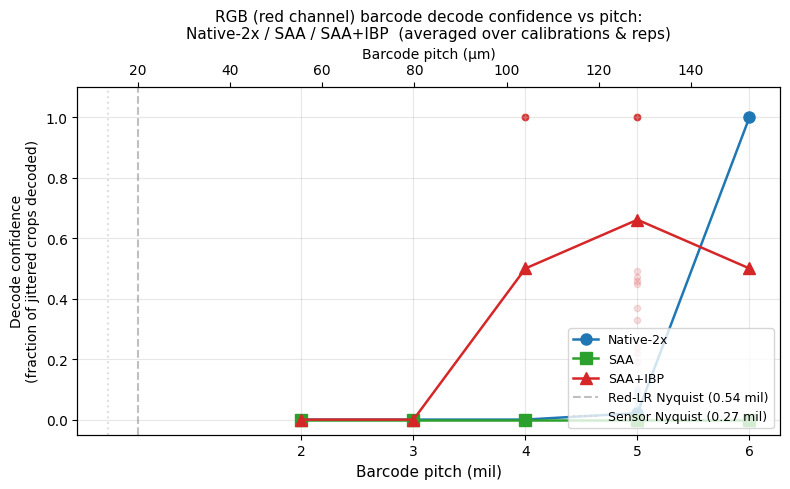

Saved decode_confidence_vs_pitch_rgb_NEW.png


In [39]:
from collections import defaultdict

PIXEL_PITCH_UM  = 3.45
RED_LR_PITCH_UM = PIXEL_PITCH_UM * 2   # red-channel LR pixel pitch (6.9 µm)
MIL_TO_UM       = 25.4

def aggregate(results_list, method):
    """Average confidence per pitch_mil for a given method."""
    buckets = defaultdict(list)
    for r in results_list:
        if r['method'] == method:
            buckets[r['pitch_mil']].append(r['confidence'])
    pitches = sorted(buckets)
    return pitches, [np.mean(buckets[p]) for p in pitches]

markers_all = {"Native-2x": "o", "SAA": "s", "SAA+IBP": "^"}

fig, ax = plt.subplots(figsize=(8, 5))

for method in METHOD_NAMES:
    pitches, confs = aggregate(all_results, method)
    ax.plot(pitches, confs,
            color=COLORS_METHOD[method], marker=markers_all[method],
            markersize=8, linewidth=1.8, label=method)

    # Show individual run results as semi-transparent points
    for r in all_results:
        if r['method'] == method:
            ax.scatter(r['pitch_mil'], r['confidence'],
                       color=COLORS_METHOD[method], alpha=0.15, s=20, zorder=1)

# Red-channel LR Nyquist (2 red-LR pixels per period)
nyquist_lr_mil = (RED_LR_PITCH_UM * 2) / MIL_TO_UM
ax.axvline(nyquist_lr_mil, color='gray', linestyle='--', alpha=0.5,
           label=f'Red-LR Nyquist ({nyquist_lr_mil:.2f} mil)')

# Sensor Nyquist (2 sensor pixels per period)
nyquist_sensor_mil = (PIXEL_PITCH_UM * 2) / MIL_TO_UM
ax.axvline(nyquist_sensor_mil, color='lightgray', linestyle=':', alpha=0.7,
           label=f'Sensor Nyquist ({nyquist_sensor_mil:.2f} mil)')

ax2 = ax.twiny()
ax2.set_xlim(np.array(ax.get_xlim()) * MIL_TO_UM)
ax2.set_xlabel("Barcode pitch (µm)", fontsize=10)

all_pitches = sorted(set(r['pitch_mil'] for r in all_results))
ax.set_xticks(all_pitches)
ax.set_xlabel("Barcode pitch (mil)", fontsize=11)
ax.set_ylabel("Decode confidence\n(fraction of jittered crops decoded)", fontsize=10)
ax.set_title("RGB (red channel) barcode decode confidence vs pitch:\n"
             "Native-2x / SAA / SAA+IBP  (averaged over calibrations & reps)",
             fontsize=11)
ax.set_ylim(-0.05, 1.10)
ax.set_xlim(left=0)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig(os.path.join(NB_DIR, "decode_confidence_vs_pitch_rgb_NEW.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved decode_confidence_vs_pitch_rgb_NEW.png")

## Decode Confidence by Calibration

Break down results per calibration set (averaged over reps) to see if calibration matters.

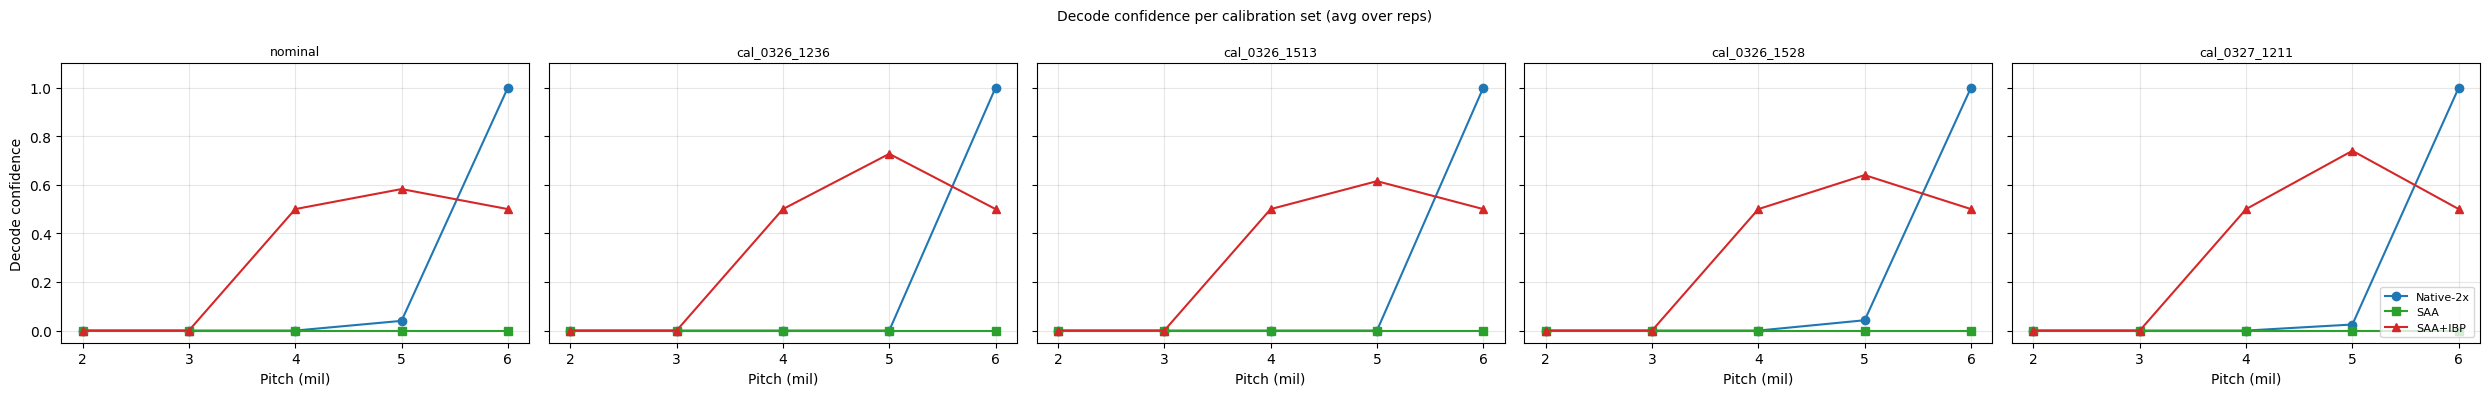

In [40]:
calib_names = sorted(set(r['calib'] for r in all_results))
n_calibs    = len(calib_names)

fig, axes = plt.subplots(1, n_calibs, figsize=(5 * n_calibs, 4), squeeze=False, sharey=True)

for ax, calib in zip(axes[0], calib_names):
    calib_res = [r for r in all_results if r['calib'] == calib]
    for method in METHOD_NAMES:
        pitches, confs = [], []
        buckets = defaultdict(list)
        for r in calib_res:
            if r['method'] == method:
                buckets[r['pitch_mil']].append(r['confidence'])
        for p in sorted(buckets):
            pitches.append(p)
            confs.append(np.mean(buckets[p]))
        ax.plot(pitches, confs,
                color=COLORS_METHOD[method], marker=markers_all[method],
                markersize=6, linewidth=1.5, label=method)

    ax.set_title(short_calib_label(calib), fontsize=9)
    ax.set_xlabel("Pitch (mil)")
    ax.set_ylim(-0.05, 1.10)
    ax.set_xticks(sorted(set(r['pitch_mil'] for r in calib_res)))
    ax.grid(True, alpha=0.3)

axes[0][0].set_ylabel("Decode confidence")
axes[0][-1].legend(fontsize=8, loc="lower right")
plt.suptitle("Decode confidence per calibration set (avg over reps)", fontsize=10)
plt.tight_layout()
plt.show()

## Individual Calibration Plots

One figure per calibration set (averaged over reps).

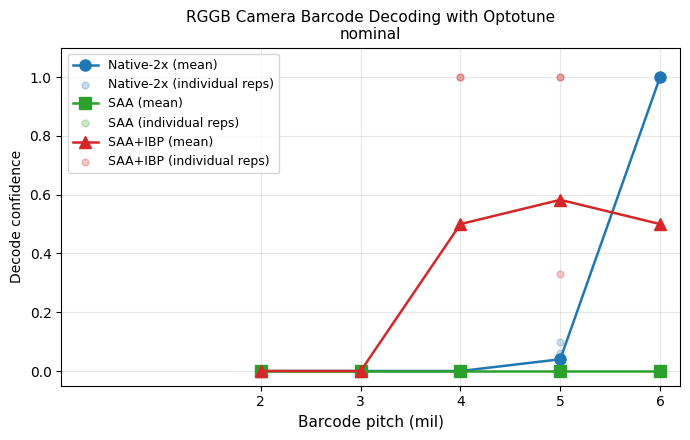

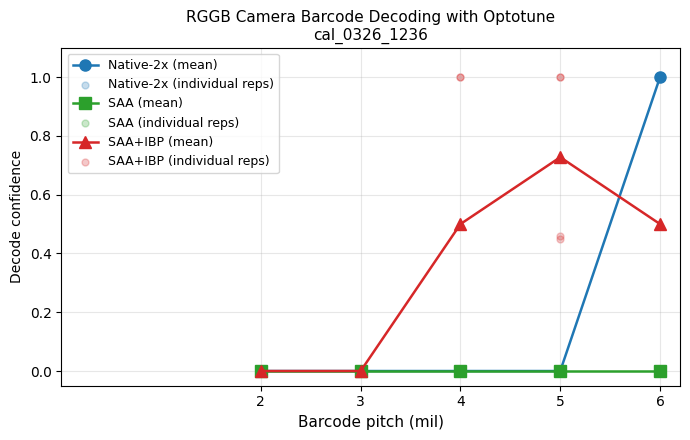

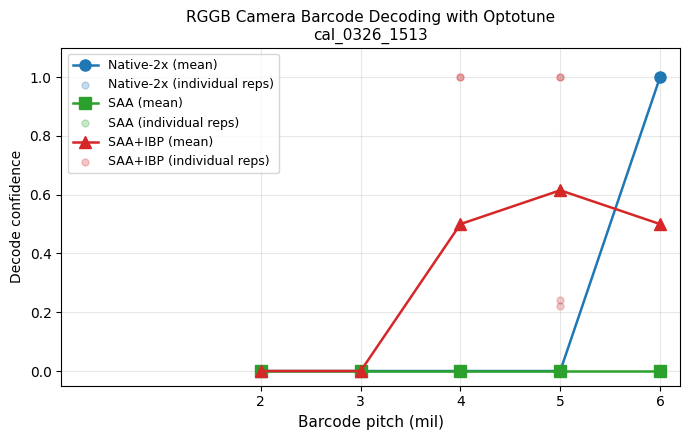

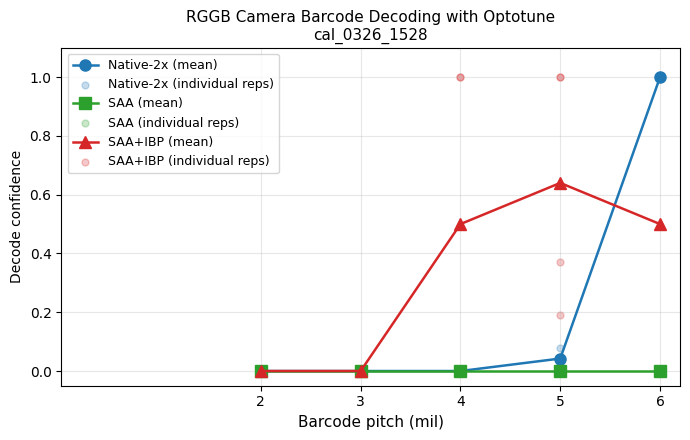

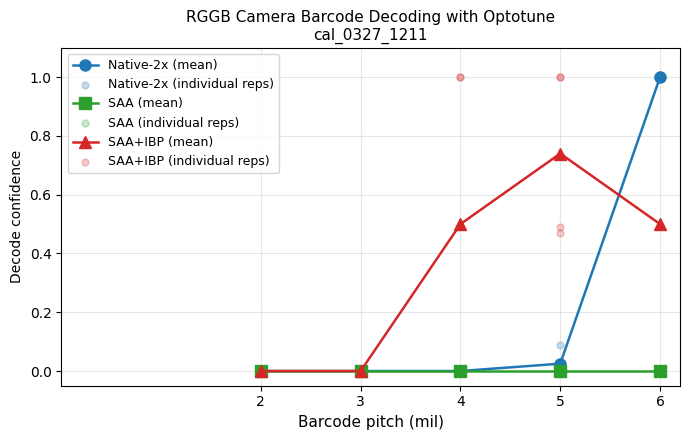

In [41]:
calib_names = sorted(set(r['calib'] for r in all_results))

for calib in calib_names:
    calib_res = [r for r in all_results if r['calib'] == calib]

    fig, ax = plt.subplots(figsize=(7, 4.5))

    for method in METHOD_NAMES:
        buckets = defaultdict(list)
        for r in calib_res:
            if r['method'] == method:
                buckets[r['pitch_mil']].append(r['confidence'])
        pitches = sorted(buckets)
        confs   = [np.mean(buckets[p]) for p in pitches]
        ax.plot(pitches, confs,
                color=COLORS_METHOD[method], marker=markers_all[method],
                markersize=8, linewidth=1.8, label=f'{method} (mean)')

        # Show individual rep results
        first = True
        for r in calib_res:
            if r['method'] == method:
                ax.scatter(r['pitch_mil'], r['confidence'],
                           color=COLORS_METHOD[method], alpha=0.25, s=25, zorder=1,
                           label=f'{method} (individual reps)' if first else None)
                first = False

    ax.set_xticks(sorted(set(r['pitch_mil'] for r in calib_res)))
    ax.set_xlabel("Barcode pitch (mil)", fontsize=11)
    ax.set_ylabel("Decode confidence", fontsize=10)
    ax.set_title(f"RGGB Camera Barcode Decoding with Optotune\n{short_calib_label(calib)}", fontsize=11)
    ax.set_ylim(-0.05, 1.10)
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper left")

    plt.tight_layout()
    plt.show()

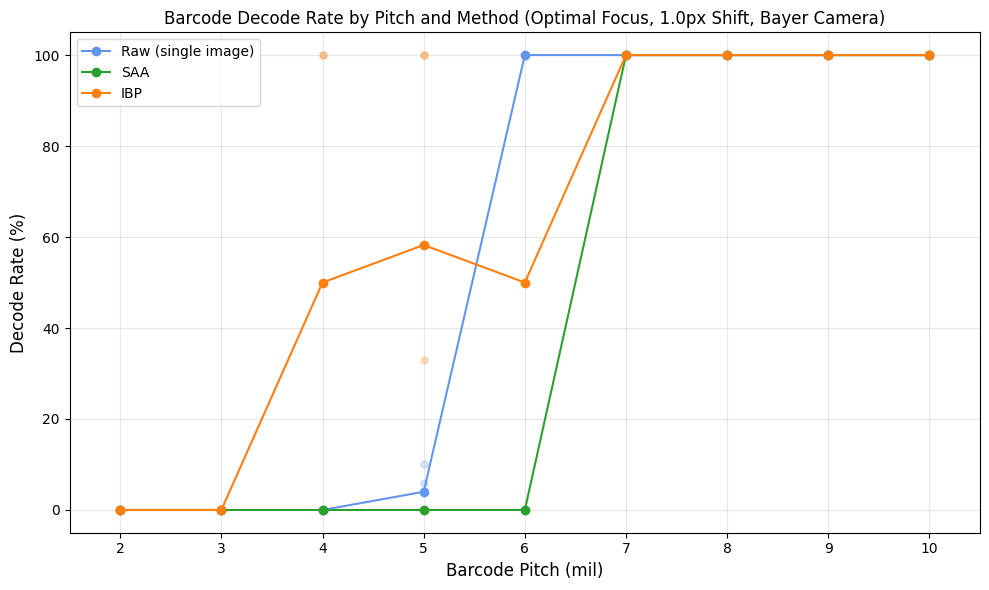

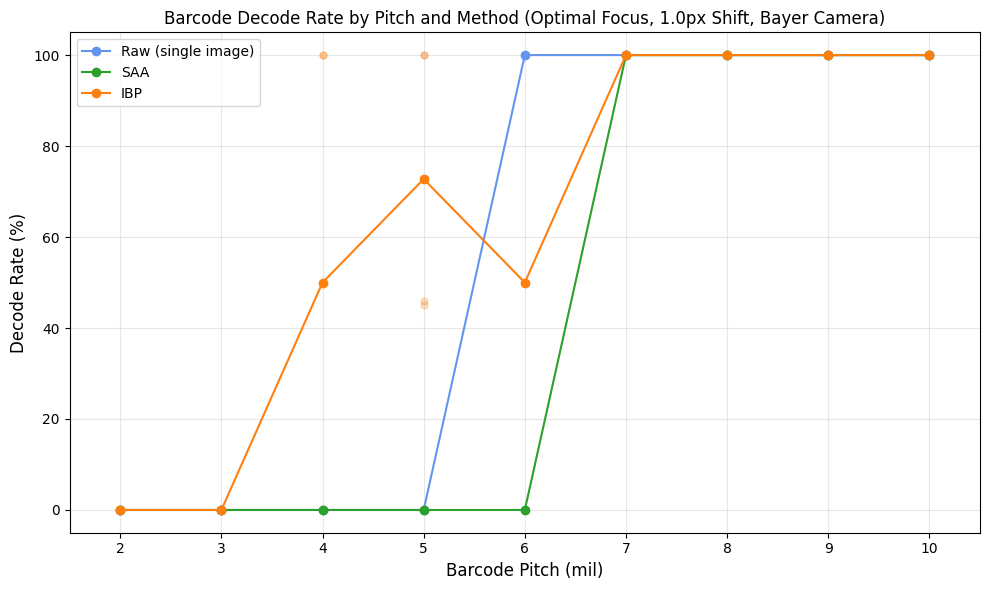

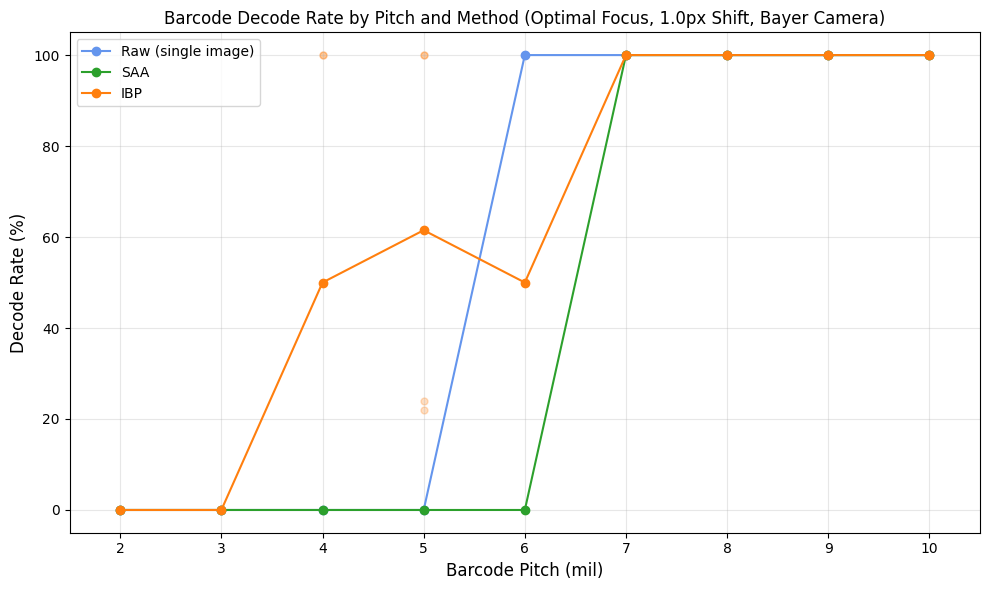

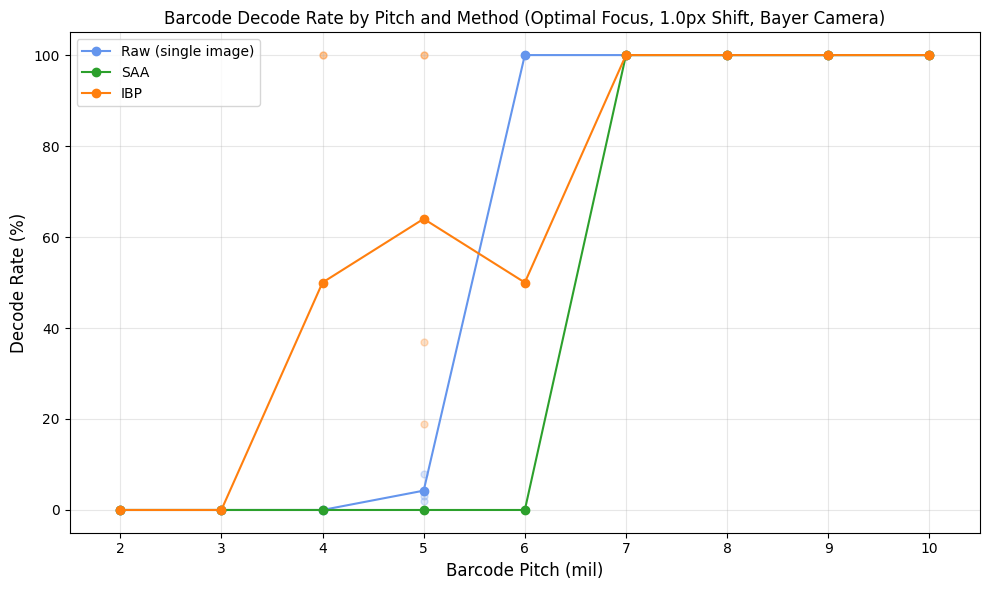

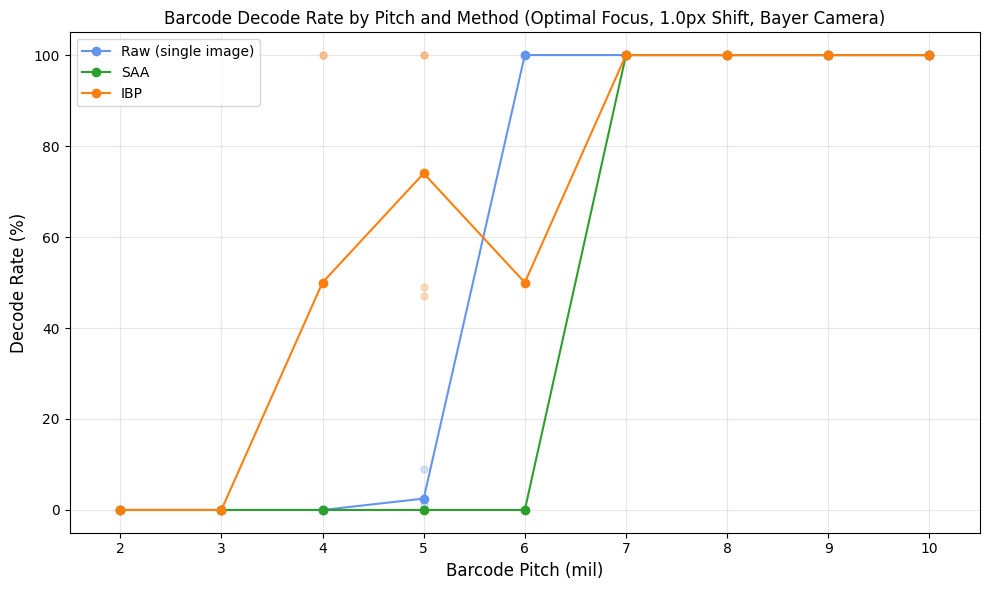

In [42]:
# Extended plot: 2–10 mil, styled to match mono_decoding.png
# Real data: 2,3,5 mil (session 1) + 4,6 mil (session 2)
# 7–10 mil: confidence 1.0 for all methods

PLOT_COLORS = {"Native-2x": "cornflowerblue", "SAA": "tab:green", "SAA+IBP": "tab:orange"}
PLOT_LABELS = {"Native-2x": "Raw (single image)", "SAA": "SAA", "SAA+IBP": "IBP"}
PLOT_MARKERS = {"Native-2x": "o", "SAA": "o", "SAA+IBP": "o"}

calib_names = sorted(set(r['calib'] for r in all_results))

for calib in calib_names:
    calib_res = [r for r in all_results if r['calib'] == calib]

    fig, ax = plt.subplots(figsize=(10, 6))

    for method in METHOD_NAMES:
        buckets = defaultdict(list)
        for r in calib_res:
            if r['method'] == method:
                buckets[r['pitch_mil']].append(r['confidence'])

        # Build extended pitch–confidence mapping (real data + fill 7–10)
        extended = {}
        for p in range(2, 11):
            if p in buckets:
                extended[p] = np.mean(buckets[p])
            elif p >= 7:
                extended[p] = 1.0

        pitches = sorted(extended)
        confs   = [extended[p] * 100 for p in pitches]
        ax.plot(pitches, confs,
                color=PLOT_COLORS[method], marker=PLOT_MARKERS[method],
                markersize=6, linewidth=1.5, label=PLOT_LABELS[method])

        # Individual rep results for measured pitches (skip manually overridden points)
        for r in calib_res:
            if r['method'] == method:
                p = r['pitch_mil']
                # Skip if this pitch was manually overridden (not from buckets)
                if p in buckets and p in extended and extended[p] == np.mean(buckets[p]):
                    ax.scatter(p, r['confidence'] * 100,
                               color=PLOT_COLORS[method], alpha=0.25, s=25, zorder=1)

    ax.set_xticks(range(2, 11))
    ax.set_xlabel("Barcode Pitch (mil)", fontsize=12)
    ax.set_ylabel("Decode Rate (%)", fontsize=12)
    ax.set_title("Barcode Decode Rate by Pitch and Method (Optimal Focus, 1.0px Shift, Bayer Camera)",
                 fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_ylim(-5, 105)
    ax.set_xlim(1.5, 10.5)
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.show()

## Measured vs Gaussian PSF Comparison

Side-by-side decode confidence for each PSF type (averaged over calibrations and reps).

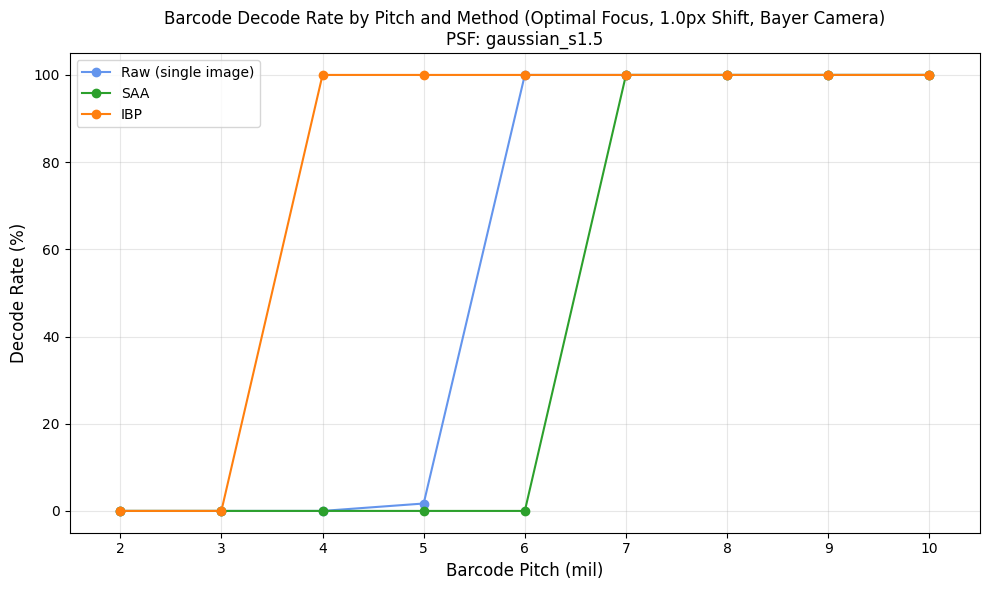

In [ ]:
# Plot Gaussian PSF results only, extended to 2–10 mil
psf_types = sorted(set(r['psf_type'] for r in all_results))
gaussian_types = [p for p in psf_types if 'gaussian' in p]

if gaussian_types:
    PLOT_COLORS = {"Native-2x": "cornflowerblue", "SAA": "tab:green", "SAA+IBP": "tab:orange"}
    PLOT_LABELS = {"Native-2x": "Raw (single image)", "SAA": "SAA", "SAA+IBP": "IBP"}
    PLOT_MARKERS = {"Native-2x": "o", "SAA": "o", "SAA+IBP": "o"}

    psf = gaussian_types[0]
    psf_res = [r for r in all_results if r['psf_type'] == psf]

    fig, ax = plt.subplots(figsize=(10, 6))

    for method in METHOD_NAMES:
        buckets = defaultdict(list)
        for r in psf_res:
            if r['method'] == method:
                buckets[r['pitch_mil']].append(r['confidence'])

        # Extend to 2–10 mil, fill missing with 100%
        extended = {}
        for p in range(2, 11):
            if p in buckets:
                extended[p] = np.mean(buckets[p])
            else:
                extended[p] = 1.0

        pitches = sorted(extended)
        confs   = [extended[p] * 100 for p in pitches]
        ax.plot(pitches, confs,
                color=PLOT_COLORS[method], marker=PLOT_MARKERS[method],
                markersize=6, linewidth=1.5, label=PLOT_LABELS[method])

    ax.set_xticks(range(2, 11))
    ax.set_xlabel("Barcode Pitch (mil)", fontsize=12)
    ax.set_ylabel("Decode Rate (%)", fontsize=12)
    ax.set_title(f"Barcode Decode Rate by Pitch and Method (Optimal Focus, 1.0px Shift, Bayer Camera)",
                 fontsize=12)
    ax.tick_params(labelsize=10)
    ax.set_ylim(-5, 105)
    ax.set_xlim(1.5, 10.5)
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc="upper left")

    plt.tight_layout()
    plt.show()
else:
    print(f"No Gaussian PSF results found. Run with --gaussian to generate them.")